## `localK` and `localL`

`pointpats` provides per-point versions of Ripley's K and L functions.

For each point $i$, $K_i(r)$ counts the expected number of additional points within
distance $r$, normalised by $\lambda_1 = (n-1)/|W|$.  For a CSR pattern,
$E[K_i(r)] = \pi r^2$.  The local L is simply $L_i(r) = \sqrt{K_i(r)/\pi}$.

Three edge corrections are supported: `None` (uncorrected), `'isotropic'` (Ripley,
the default, matching spatstat's `correction="Ripley"`), and `'translate'` (Ohser & Stoyan).

80 points in a 10×10 window


<Axes: >

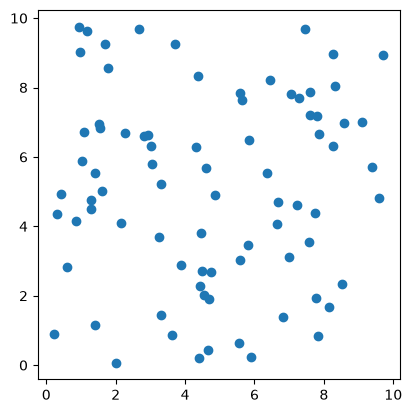

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
from pointpats import localK, localL
from pointpats import random as ppr

rng = np.random.default_rng(42)
window = shapely.box(0, 0, 10, 10)
points = ppr.poisson(window, size=80, rng=rng)
print(f"{len(points)} points in a 10×10 window")
shapely_pts = shapely.points(points[:, 0], points[:, 1])
pnt_gdf = gpd.GeoDataFrame(geometry=shapely_pts)
pnt_gdf.plot()

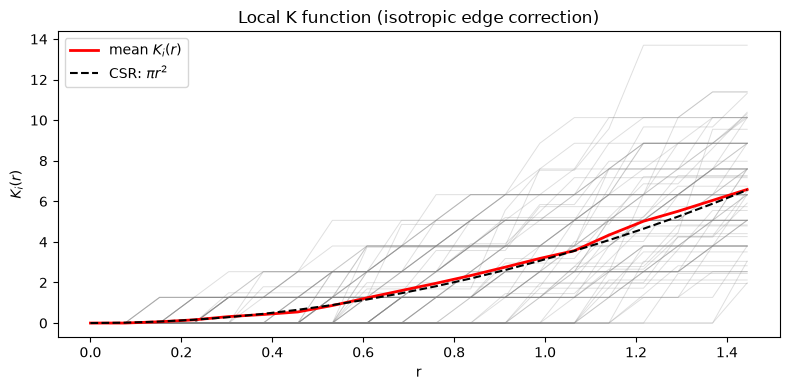

In [19]:
# Local K with isotropic edge correction (spatstat default)
support, lk = localK(points, hull=window, support=20)

fig, ax = plt.subplots(figsize=(8, 4))
for i in range(len(points)):
    ax.plot(support, lk[:, i], color="gray", alpha=0.25, lw=0.7)
ax.plot(support, lk.mean(axis=1), color="red", lw=2, label=r"mean $K_i(r)$")
ax.plot(support, np.pi * support**2, "k--", lw=1.5, label=r"CSR: $\pi r^2$")
ax.set_xlabel("r")
ax.set_ylabel(r"$K_i(r)$")
ax.set_title("Local K function (isotropic edge correction)")
ax.legend()
plt.tight_layout()
plt.show()

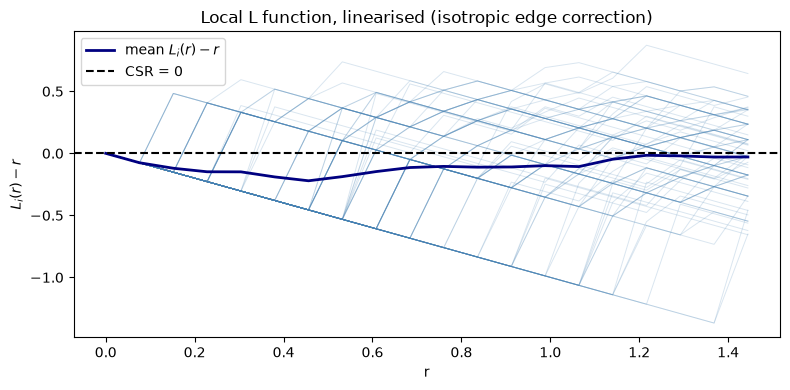

In [20]:
# Linearised local L: L_i(r) - r, centred on 0 for CSR
support, ll_lin = localL(points, hull=window, support=20, linearized=True)

fig, ax = plt.subplots(figsize=(8, 4))
for i in range(len(points)):
    ax.plot(support, ll_lin[:, i], color="steelblue", alpha=0.2, lw=0.7)
ax.plot(support, ll_lin.mean(axis=1), color="navy", lw=2, label=r"mean $L_i(r) - r$")
ax.axhline(0, color="k", lw=1.5, ls="--", label="CSR = 0")
ax.set_xlabel("r")
ax.set_ylabel(r"$L_i(r) - r$")
ax.set_title("Local L function, linearised (isotropic edge correction)")
ax.legend()
plt.tight_layout()
plt.show()

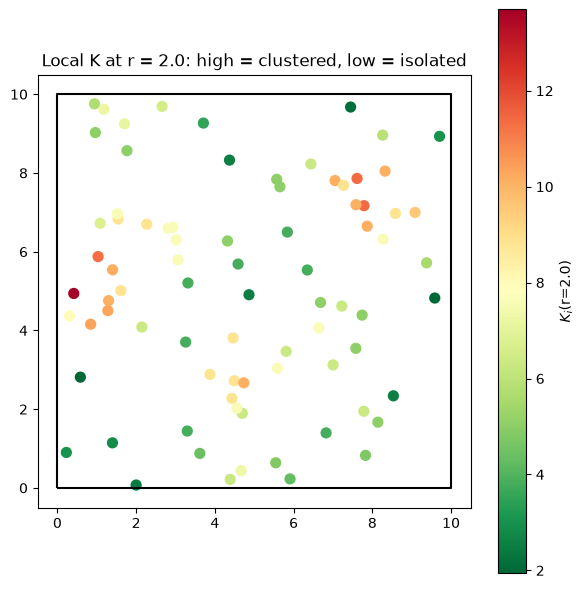

In [21]:
# Map: colour each point by its local K value at a chosen radius
r_target = 2.0
r_idx = np.argmin(np.abs(support - r_target))
ki_at_r = lk[r_idx]   # K_i(r_target) for every point

shapely_pts = shapely.points(points[:, 0], points[:, 1])
pnt_gdf = gpd.GeoDataFrame({"K_local": ki_at_r}, geometry=shapely_pts)
win_gdf = gpd.GeoDataFrame(geometry=[window])

fig, ax = plt.subplots(figsize=(6, 6))
win_gdf.boundary.plot(ax=ax, color="k")
pnt_gdf.plot(
    column="K_local", legend=True, ax=ax,
    markersize=50, cmap="RdYlGn_r",
    legend_kwds={"label": f"$K_i$(r={r_target})"},
)
ax.set_title(f"Local K at r = {r_target}: high = clustered, low = isolated")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

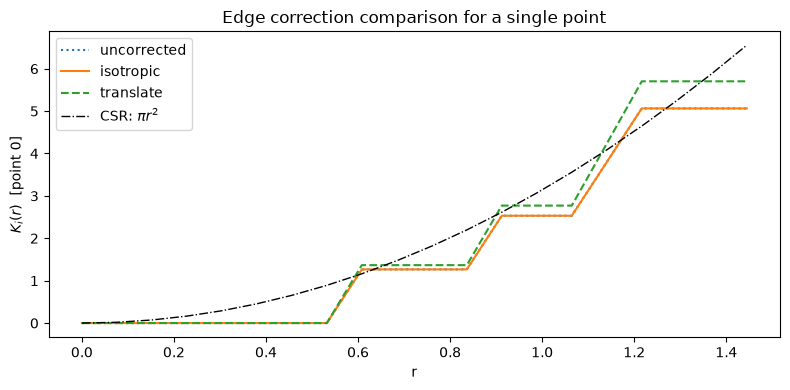

In [22]:
# Compare edge corrections for a single point
support, lk_none = localK(points, hull=window, support=20, edge_correction=None)
support, lk_iso  = localK(points, hull=window, support=20, edge_correction="isotropic")
support, lk_tra  = localK(points, hull=window, support=20, edge_correction="translate")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(support, lk_none[:, 0], label="uncorrected", ls=":")
ax.plot(support, lk_iso[:, 0],  label="isotropic",   ls="-")
ax.plot(support, lk_tra[:, 0],  label="translate",   ls="--")
ax.plot(support, np.pi * support**2, "k-.", lw=1, label=r"CSR: $\pi r^2$")
ax.set_xlabel("r")
ax.set_ylabel(r"$K_i(r)$  [point 0]")
ax.set_title("Edge correction comparison for a single point")
ax.legend()
plt.tight_layout()
plt.show()